In [1]:
import sys, common, pickle, collections, numpy
import pandas as pd
import matplotlib.pyplot as plt
from logJosh import Tee
import prince

In [7]:
def parsePickleFile(pickleFile):
    """
    Given Liam's pickle file, will output a dict of the format:
    {bc:{readID:{position:edit}}} where position has to be an A in the ref
    """
    with open(pickleFile,'rb') as f:
        dataDict=pickle.load(f)
    ##
    bb=collections.defaultdict(lambda:collections.defaultdict(dict))
    ##
    for readID,subDict in dataDict.items():
        barCode=subDict['barcode']
        #print(barCode,readID)
        editString=subDict['edit_string']
        #print(editString,len(editString))
        readSeq=subDict['read_sequence_aligned']
        #print(readSeq,len(readSeq))
        refSeq=subDict['ref_sequence_aligned']
        #print(refSeq,len(refSeq))
        alignedPairs=subDict['aligned_pairs']
        #print(alignedPairs,len(alignedPairs))
        #sys.exit()
        for ii in range(len(alignedPairs)-1):
            entry=alignedPairs[ii]
            idx=entry[0]
            absIdx=entry[1]
            if idx!=None and absIdx!=None:
                seq=refSeq[ii]
                edit=editString[ii]
                if seq=='A' and edit!='2' and absIdx<=695:
                    ##695 is where the RT primer binds--anything past this
                    ##is artifact.
                    bb[barCode][readID][absIdx]=int(edit)
    ##
    return bb

def formatForMCA(dataDict,numReads,minEditFreq):
    """
    dataDict={bc:{readID:{position:1/0}}}
    numReads is an integer.
    minEditFreq is a frequency (e.g., 0.7)
    Will sort each bc's readIDs by longest -> shortest, and then select the
    numReads longest reads with at least minEditFreq of 1's
    Will then convert to a list-of-lists like:
    [[0,1,1,0,...,1],
     [1,1,0,1,...,1],
     ...
     [1,0,0,0,...,0]]
     where each row represents a different readID. Will also return a list
     of bcs, which are the row labels.
    """
    aa=[]
    ##This part just gets the numReads reads from each bc
    for bc,readDict in dataDict.items():
        temp=[]
        for readID,positDict in readDict.items():
            if sum(positDict.values())/len(positDict)>=minEditFreq:
                temp.append(len(positDict))
        ##
        temp.sort()
        temp.reverse()
        ##
        temp2=[]
        for readID,positDict in readDict.items():
            if len(positDict) in temp[:numReads]:
                if sum(positDict.values())/len(positDict)>=minEditFreq:
                    temp2.append((bc,positDict))
            if len(temp2)==numReads:
                break
        ##
        aa+=temp2
    ##
    ##now get all the positions
    positions=[]
    for entry in aa:
        for k in entry[1]:
            positions.append(k)
    ##now get unique positions, and then sort them
    positions=list(set(positions))
    positions.sort()
    ##now prepare outputs
    matrixOfEdits=[]
    listOfBCs=[]
    for entry in aa:
        ##record the bc
        listOfBCs.append(entry[0])
        ##now convert the dict to a vector/list
        temp=[]
        for k in positions:
            if k in entry[1]:
                v=entry[1][k]
            else:
                v=numpy.nan##in case no value
            temp.append(v)
        ##
        matrixOfEdits.append(temp)
    ##
    return matrixOfEdits,listOfBCs

def doMCAandPlot(matrixOfEdits,listOfBCs,outPrefix):
    """
    matrixOfEdits is a list of lists, where each list is a list of 1/0/nan
    indicated edit status. listOfBCs are the labels associated with that.
    Will run MCA and plot the first two components.
    """
    ##convert to DF
    X = pd.DataFrame(matrixOfEdits,\
        columns=['A%s'%(ii) for ii in range(len(matrixOfEdits[0]))])
    ##initialize mca
    mca = prince.MCA(n_components=5, n_iter=5, \
        copy=True, check_input=True, engine='sklearn', \
        random_state=42)
    ##
    mca_fit = mca.fit(X)
    X_mca = mca_fit.transform(X)
    ##create labels, but don't actually attached them to the DF
    labels = pd.Series(listOfBCs, name='label')
    ##add the labels
    X_mca['label'] = labels.values
    ##print some results
    print(mca.eigenvalues_summary)
    print(mca.column_coordinates(X))
    ##
    for ii in range(4):
        ##plot the data
        fig, ax = plt.subplots(figsize=(6, 6))
        for label in X_mca['label'].unique():
            subset = X_mca[X_mca['label'] == label]
            ax.scatter(subset[ii], subset[ii+1], label=label)
        ##set axis labels
        ax.set_title('MCA of Binary Vectors')
        ax.set_xlabel('MCA Dimension %s'%(ii+1))##+1 b/c python 0-based
        ax.set_ylabel('MCA Dimension %s'%(ii+2))
        ax.legend()
        ##save output
        plt.savefig('%s.%s.%s.png'%(outPrefix,ii,ii+1))
        plt.show()
        plt.close()

In [8]:
from pathlib import Path
pickleFile = Path('/data16/liam/working/data/alignments/250509_JANP-112_LT/250703_pickles/merged_barcodes_nanoluc_translatable.pickle')
numReads = 50
minEdit = 0.8
outPrefix = Path('/data16/liam/working/data/alignments/250509_JANP-112_LT/pca_testing/260204_test')

4
200
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.049         4.92%                      4.92%
1              0.037         3.69%                      8.61%
2              0.033         3.31%                     11.91%
3              0.026         2.56%                     14.47%
4              0.023         2.30%                     16.77%
                  0         1         2         3         4
A0__0.0   -0.734032 -0.087739  0.034460 -0.450994 -0.423432
A0__1.0    0.060093  0.037046 -0.042017  0.013502  0.070871
A1__0.0    0.307722 -0.667390  0.541626 -0.691629  0.036962
A1__1.0   -0.018939  0.015908 -0.007620  0.011728 -0.001220
A2__0.0   -0.316604  0.152302 -0.142491 -0.432589  0.142447
...             ...       ...       ...       ...       ...
A234__1.0 -0.004574 -0.006316  0.004595  0.011361  0.000324
A235__0.0  0.037454  1.072710 -0.601980 -0.190111 -0.178762
A235__1.0 -0.012368 

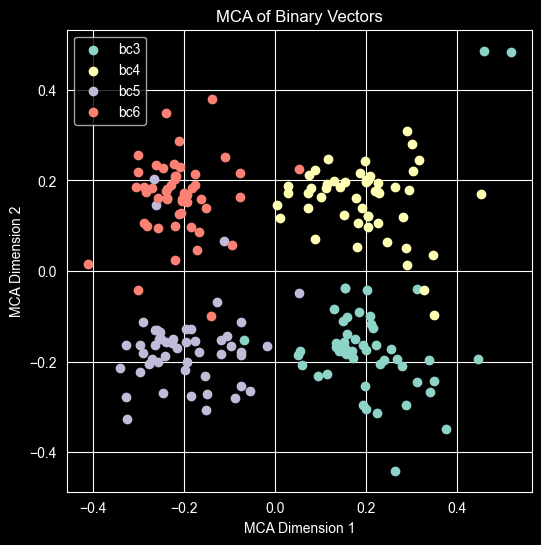

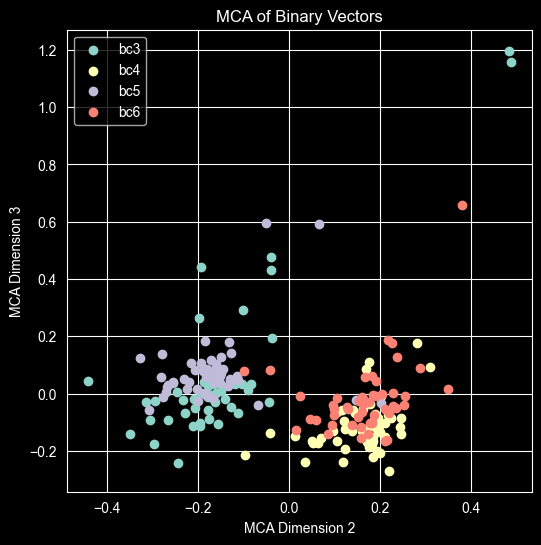

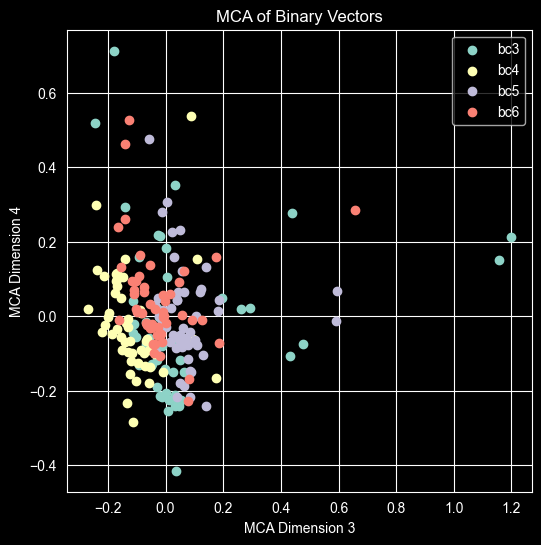

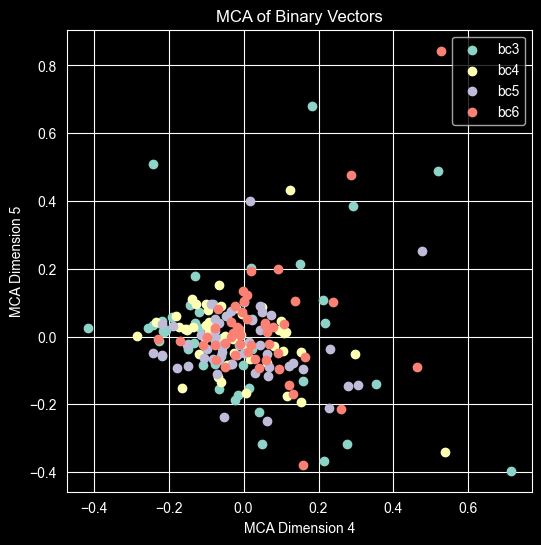

In [9]:
dataDict=parsePickleFile(pickleFile)
print(len(dataDict))
##
matrixOfEdits,listOfBCs=formatForMCA(dataDict,int(numReads),\
    float(minEdit))
print(len(matrixOfEdits))
##
doMCAandPlot(matrixOfEdits,listOfBCs,outPrefix)

### Let's test PCA on the same set of reads

In [10]:
def formatForMCA2(dataDict,numReads,minEditFreq):
    """
    same as formatForMCA but will return a list of Read IDs as well.
    """
    aa=[]
    ##This part just gets the numReads reads from each bc
    for bc,readDict in dataDict.items():
        temp=[]
        for readID,positDict in readDict.items():
            if sum(positDict.values())/len(positDict)>=minEditFreq:
                temp.append(len(positDict))
        ##
        temp.sort()
        temp.reverse()
        ##
        temp2=[]
        for readID,positDict in readDict.items():
            if len(positDict) in temp[:numReads]:
                if sum(positDict.values())/len(positDict)>=minEditFreq:
                    temp2.append((readID,bc,positDict))
            if len(temp2)==numReads:
                break
        ##
        aa+=temp2
    ##
    ##now get all the positions
    positions=[]
    for entry in aa:
        for k in entry[2]:##2 b/c readID, bc, positDict
            positions.append(k)
    ##now get unique positions, and then sort them
    positions=list(set(positions))
    positions.sort()
    ##now prepare outputs
    matrixOfEdits=[]
    listOfBCs=[]
    listOfReadIDs=[]
    for entry in aa:
        ##record the readID
        listOfReadIDs.append(entry[0])
        ##record the bc
        listOfBCs.append(entry[1])
        ##now convert the dict to a vector/list
        temp=[]
        for k in positions:
            if k in entry[2]:##2 b/c readID, bc, positDict
                v=entry[2][k]
            else:
                v=numpy.nan##in case no value
            temp.append(v)
        ##
        matrixOfEdits.append(temp)
    ##
    return matrixOfEdits,listOfBCs,listOfReadIDs

4
200
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.049         4.92%                      4.92%
1              0.037         3.69%                      8.61%
2              0.033         3.31%                     11.91%
3              0.026         2.56%                     14.47%
4              0.023         2.30%                     16.77%
                  0         1         2         3         4
A0__0.0   -0.734032 -0.087739  0.034460 -0.450994 -0.423432
A0__1.0    0.060093  0.037046 -0.042017  0.013502  0.070871
A1__0.0    0.307722 -0.667390  0.541626 -0.691629  0.036962
A1__1.0   -0.018939  0.015908 -0.007620  0.011728 -0.001220
A2__0.0   -0.316604  0.152302 -0.142491 -0.432589  0.142447
...             ...       ...       ...       ...       ...
A234__1.0 -0.004574 -0.006316  0.004595  0.011361  0.000324
A235__0.0  0.037454  1.072710 -0.601980 -0.190111 -0.178762
A235__1.0 -0.012368 

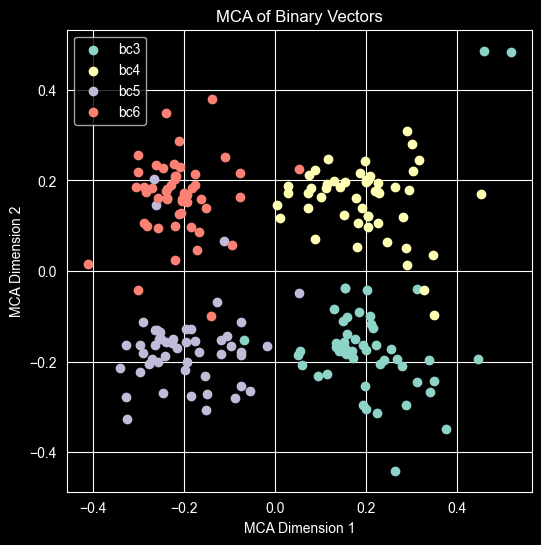

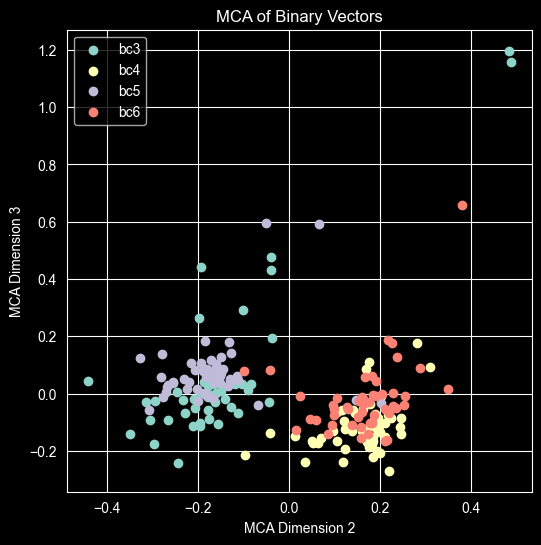

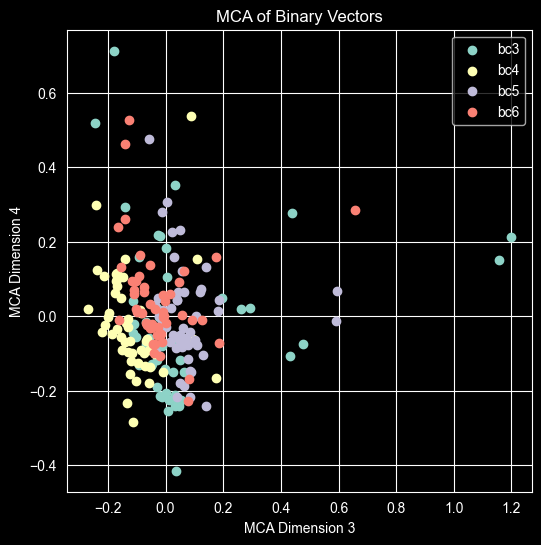

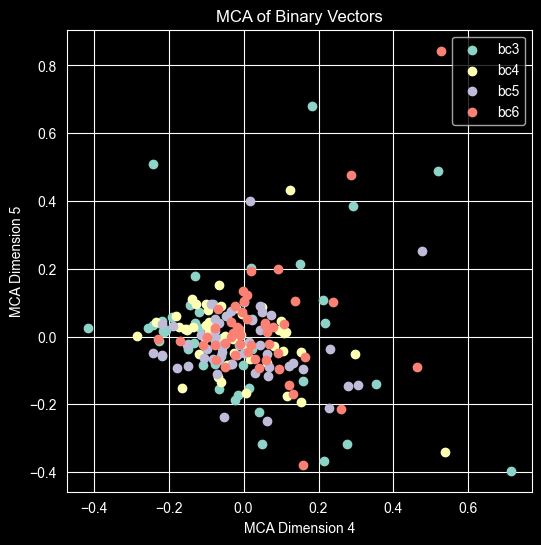

In [11]:
dataDict=parsePickleFile(pickleFile)
print(len(dataDict))
##
matrixOfEdits,listOfBCs,listOfReadIDs=formatForMCA2(dataDict,int(numReads),\
    float(minEdit))
print(len(matrixOfEdits))
##
doMCAandPlot(matrixOfEdits,listOfBCs,outPrefix)

In [12]:
print("listOfReadIDs: ", len(listOfReadIDs))

listOfReadIDs:  200


#### Let's try PCA on the same set of reads